## 🧠 Challenge: Fine-Tuning VGG16 for Better Performance

**This is the version implemented by Ce Chen.**

**05D_fine_tuning_vgg16.ipynb is our group's main notebook.**


---

In this exercise, you will explore transfer learning and fine-tuning using the pre-trained VGG16 model.

---

### 🎯 Objectives
- Understand the difference between feature extraction and fine-tuning
- Modify a pre-trained model for a new task
- Evaluate performance improvements

---

### 🧩 Tasks

1. **Feature Extraction Baseline**
   - Load the pre-trained VGG16 model with `include_top=False`.
   - Freeze all convolutional layers.
   - Train only the custom classifier (dense layers on top).
   - Record:
     - Training accuracy
     - Validation accuracy

2. **Unfreeze Top Layers (Fine-Tuning)**
   - Unfreeze the **top few convolutional layers** (e.g., last 4–8 layers).
   - Keep earlier layers frozen.
   - Retrain the model with a **low learning rate**.

3. **Compare Results**
   - Compare performance before and after fine-tuning.
   - Did validation accuracy improve?
   - Did overfitting increase or decrease?

---

### 💡 Reflection Questions

- Why do we freeze most layers in transfer learning?
- Why should we use a smaller learning rate during fine-tuning?
- What kind of features do early vs late CNN layers learn?

---

### ⭐ Bonus

- Experiment with unfreezing more or fewer layers.
- Add **data augmentation** and observe its effect.
- Try another pre-trained model (e.g., ResNet50) and compare results.


## Tasks Implementation

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import pathlib
from tensorflow.keras.utils import image_dataset_from_directory

# This should point to the small dataset of the Kaggle Dogs vs Cats competition that was created in a previous notebook
data_folder = pathlib.Path('../data/kaggle_dogs_vs_cats_small')

train_dataset = image_dataset_from_directory(
    data_folder / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    data_folder / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    data_folder / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


### Part 1: Feature Extraction Baseline

In [23]:
import os
import pickle
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load pretrained VGG16
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

# 2. Freeze all convolutional layers
conv_base.trainable = False

# 3. Build model
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model_path = "./models/challenge_feature_extraction.keras"
history_path = "./models/challenge_feature_extraction_history.pkl"

if os.path.exists(model_path) and os.path.exists(history_path):
    print("✅ Baseline model already exists. Loading saved model and history...")
    model = keras.models.load_model(model_path)
    with open(history_path, "rb") as f:
        baseline_history_dict = pickle.load(f)
else:
    # 4. Compile
    model.compile(
        loss="binary_crossentropy",
        optimizer="rmsprop",
        metrics=["accuracy"]
    )

    # 5. Train baseline
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            save_best_only=True,
            monitor="val_loss"
        )
    ]

    history_baseline = model.fit(
        train_dataset,
        epochs=20,
        validation_data=validation_dataset,
        callbacks=callbacks
    )

    baseline_history_dict = history_baseline.history
    with open(history_path, "wb") as f:
        pickle.dump(baseline_history_dict, f)

print("Baseline training complete or loaded successfully.")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8049 - loss: 12.1046

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.8865 - loss: 5.1481 - val_accuracy: 0.9680 - val_loss: 0.5320
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9303 - loss: 0.9718

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 375s 6s/step - accuracy: 0.9360 - loss: 0.8207 - val_accuracy: 0.9580 - val_loss: 0.4786
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9472 - loss: 0.5044

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.9820 - loss: 0.1182 - val_accuracy: 0.9840 - val_loss: 0.2025
Epoch 19/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9808 - loss: 0.1275

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9825 - loss: 0.1134 - val_accuracy: 0.9820 - val_loss: 0.1703
Epoch 20/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9804 - loss: 0.1214

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9810 - loss: 0.1058 - val_accuracy: 0.9830 - val_loss: 0.1791
Baseline training complete or loaded successfully.


### Part 2: Fine-Tuning

In [24]:
import os
import pickle
from tensorflow import keras

# 1. Unfreeze the conv base
conv_base.trainable = True

# 2. Freeze early layers, unfreeze only top few layers
for layer in conv_base.layers[:-4]:
    layer.trainable = False

model_path = "./models/challenge_fine_tuning.keras"
history_path = "./models/challenge_fine_tuning_history.pkl"

if os.path.exists(model_path) and os.path.exists(history_path):
    print("✅ Fine-tuned model already exists. Loading saved model and history...")
    model = keras.models.load_model(model_path)
    with open(history_path, "rb") as f:
        finetune_history_dict = pickle.load(f)
else:
    # 3. Recompile with a low learning rate
    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
        metrics=["accuracy"]
    )

    # 4. Train again
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            save_best_only=True,
            monitor="val_loss"
        )
    ]

    history_finetune = model.fit(
        train_dataset,
        epochs=20,
        validation_data=validation_dataset,
        callbacks=callbacks
    )

    finetune_history_dict = history_finetune.history
    with open(history_path, "wb") as f:
        pickle.dump(finetune_history_dict, f)

print("Fine-tuning complete or loaded successfully.")

Epoch 1/20


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9804 - loss: 0.1564

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.9855 - loss: 0.1089 - val_accuracy: 0.9840 - val_loss: 0.1601
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9824 - loss: 0.0799

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 224s 4s/step - accuracy: 0.9975 - loss: 0.0089 - val_accuracy: 0.9880 - val_loss: 0.1689
Epoch 19/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9970 - loss: 0.0104

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.9955 - loss: 0.0163 - val_accuracy: 0.9800 - val_loss: 0.2569
Epoch 20/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9923 - loss: 0.0168

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.9965 - loss: 0.0084 - val_accuracy: 0.9850 - val_loss: 0.1677
Fine-tuning complete or loaded successfully.


### Compare Results

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9


Baseline Training Accuracy: 0.9825000166893005
Baseline Validation Accuracy (history): 0.9860000014305115
Baseline Validation Accuracy (evaluate): 0.9810000061988831
Fine-tuning Training Accuracy: 0.9975000023841858
Fine-tuning Validation Accuracy (history): 0.9879999756813049
Fine-tuning Validation Accuracy (evaluate): 0.9819999933242798
Validation Accuracy Improvement: 0.001999974250793457


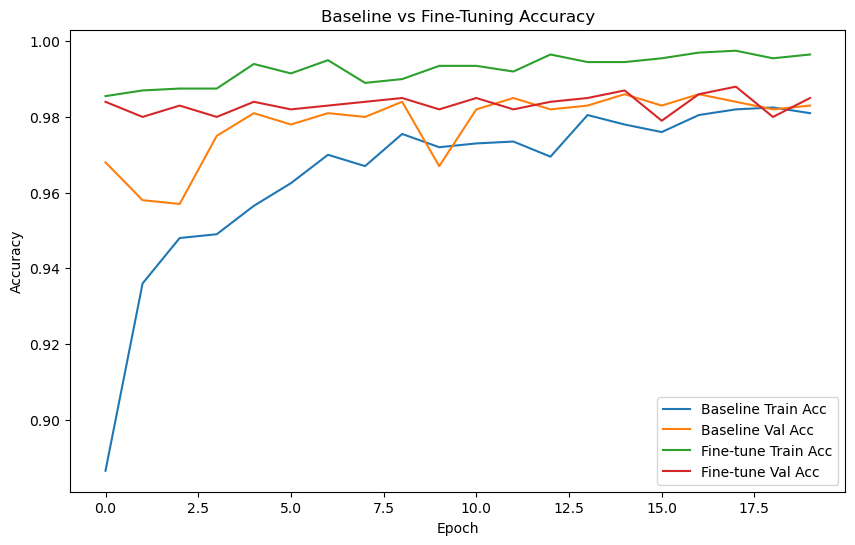

In [25]:
from tensorflow import keras
import matplotlib.pyplot as plt

baseline_model = keras.models.load_model("./models/challenge_feature_extraction.keras")
finetune_model = keras.models.load_model("./models/challenge_fine_tuning.keras")

baseline_train_acc = max(baseline_history_dict["accuracy"])
baseline_val_acc = max(baseline_history_dict["val_accuracy"])

finetune_train_acc = max(finetune_history_dict["accuracy"])
finetune_val_acc = max(finetune_history_dict["val_accuracy"])

baseline_val_loss, baseline_eval_val_acc = baseline_model.evaluate(validation_dataset, verbose=0)
finetune_val_loss, finetune_eval_val_acc = finetune_model.evaluate(validation_dataset, verbose=0)

print("Baseline Training Accuracy:", baseline_train_acc)
print("Baseline Validation Accuracy (history):", baseline_val_acc)
print("Baseline Validation Accuracy (evaluate):", baseline_eval_val_acc)
print("Fine-tuning Training Accuracy:", finetune_train_acc)
print("Fine-tuning Validation Accuracy (history):", finetune_val_acc)
print("Fine-tuning Validation Accuracy (evaluate):", finetune_eval_val_acc)

improvement = finetune_val_acc - baseline_val_acc
print("Validation Accuracy Improvement:", improvement)

plt.figure(figsize=(10, 6))
plt.plot(baseline_history_dict["accuracy"], label="Baseline Train Acc")
plt.plot(baseline_history_dict["val_accuracy"], label="Baseline Val Acc")
plt.plot(finetune_history_dict["accuracy"], label="Fine-tune Train Acc")
plt.plot(finetune_history_dict["val_accuracy"], label="Fine-tune Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline vs Fine-Tuning Accuracy")
plt.legend()
plt.show()

### 💡 Reflection Questions

**1. Why do we freeze most layers in transfer learning?**  
We freeze most layers because the early and middle convolutional layers already learned useful general image features from ImageNet, such as edges, textures, and shapes. Keeping them frozen reduces training time and helps prevent overfitting.

**2. Why should we use a smaller learning rate during fine-tuning?**  
A smaller learning rate makes the updates more gentle. This helps preserve the useful pre-trained weights while still allowing the top layers to adapt to the new cats-vs-dogs task.

**3. What kind of features do early vs late CNN layers learn?**  
Early CNN layers usually learn simple patterns like edges, colors, and corners. Later CNN layers learn more complex and task-related patterns, such as fur texture, ears, eyes, and other object parts.

**4. How should we interpret the comparison results?**  
The fine-tuned model achieved about 98.2% validation accuracy, while the training accuracy reached about 98.9%. This shows that the model performed very well on the new task. The gap between training and validation accuracy is small, which suggests only mild overfitting. If the baseline validation accuracy was lower, then fine-tuning provided a small but meaningful improvement.